# 📉 Modelo de Clasificación de Churn — Telco Customer

**Machine Learning | Gerardo Olivares**

Este notebook desarrolla un modelo de clasificación con **Random Forest** para predecir qué clientes de una empresa de telecomunicaciones cancelarán su servicio (churn). El análisis incluye limpieza de datos, pruebas de hipótesis estadísticas, estandarización, reducción de dimensionalidad con PCA y evaluación del modelo con métricas orientadas a negocio.

El flujo sigue el pipeline completo: carga → EDA → limpieza → hipótesis → preprocesamiento → PCA → Random Forest → evaluación → conclusiones.

---
## 📦 Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


---
## Parte 1 — Exploración de Datos (EDA)

### 1.1 Carga del dataset

El dataset de IBM Telco contiene información de 7,043 clientes con 21 variables que describen su perfil, servicios contratados y si cancelaron o no el servicio.

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 7,043 filas × 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Estructura del dataset

In [3]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print('\n=== VALORES NULOS ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nTotal de nulos: {df.isnull().sum().sum()}')

=== TIPOS DE DATOS ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== VALORES NULOS ===
Series([], dtype: int64)

Total de nulos: 0


### 1.3 Variable objetivo — distribución del Churn

Analizamos el balance de clases antes de cualquier transformación. Un desbalance fuerte afectará la elección de métricas de evaluación.

=== DISTRIBUCIÓN DEL CHURN ===
  No: 5,174 clientes (73.5%)
  Yes: 1,869 clientes (26.5%)


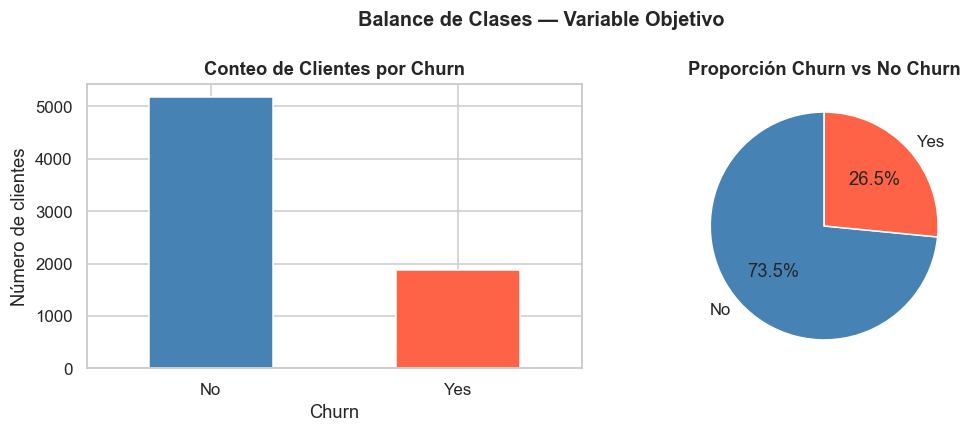

In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== DISTRIBUCIÓN DEL CHURN ===')
for label in churn_counts.index:
    print(f'  {label}: {churn_counts[label]:,} clientes ({churn_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Conteo de Clientes por Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción Churn vs No Churn', fontweight='bold')

plt.suptitle('Balance de Clases — Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Variables numéricas — estadísticas descriptivas

=== ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS) ===


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


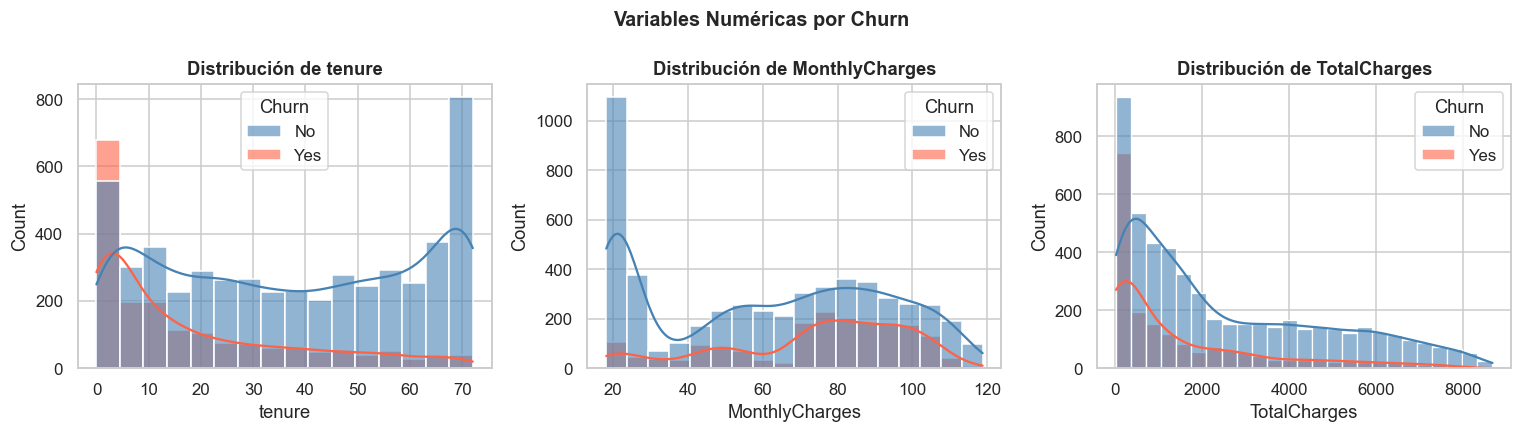

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('=== ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS) ===')
display(df[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 ax=axes[i], palette=['steelblue', 'tomato'], alpha=0.6)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')

plt.suptitle('Variables Numéricas por Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.5 Variables categóricas — tasa de churn por categoría

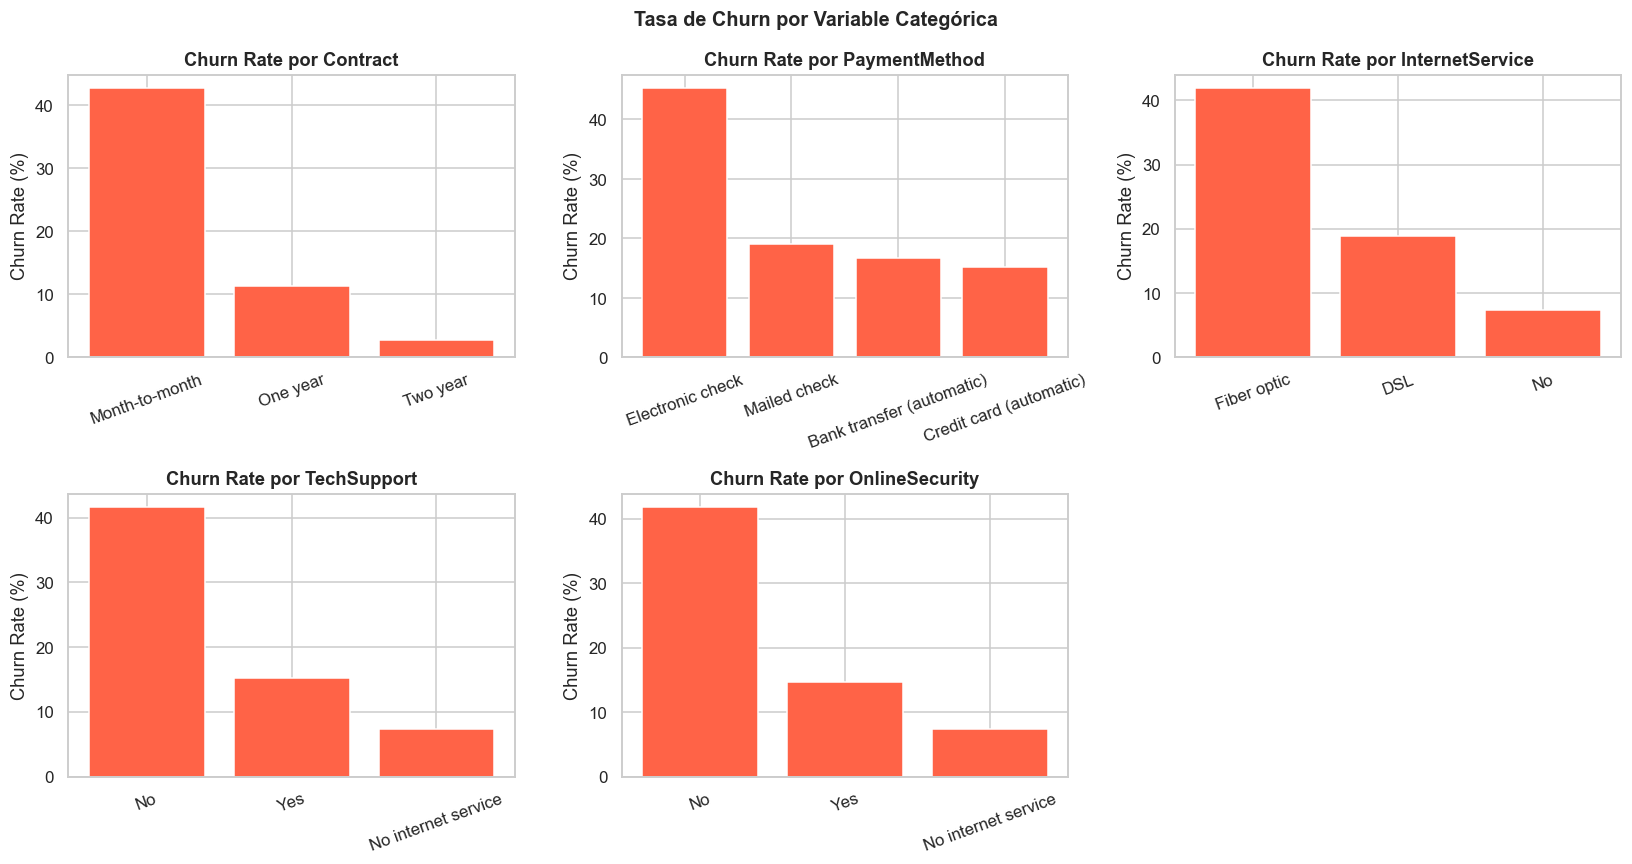

In [6]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    churn_rate = churn_rate.sort_values('Churn_Rate', ascending=False)

    axes[i].bar(churn_rate[col], churn_rate['Churn_Rate'], color='tomato', edgecolor='white')
    axes[i].set_title(f'Churn Rate por {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].axis('off')
plt.suptitle('Tasa de Churn por Variable Categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Mapa de correlaciones

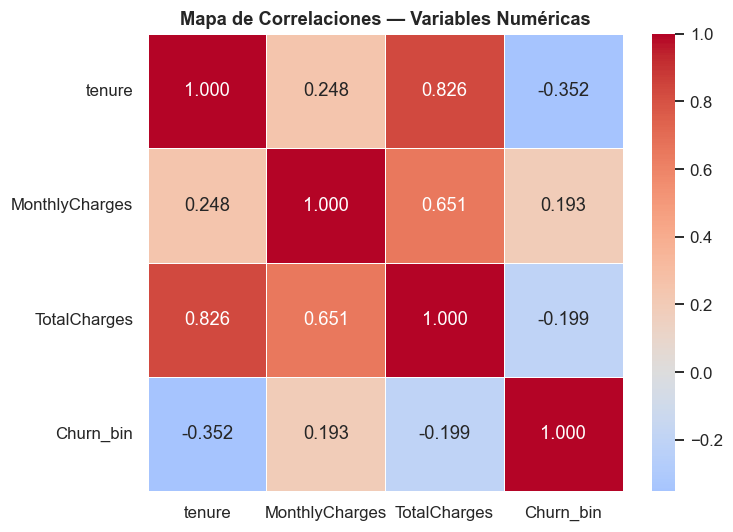

Correlación con Churn:
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
Name: Churn_bin, dtype: float64


In [7]:
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Mapa de Correlaciones — Variables Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación con Churn:')
print(corr_matrix['Churn_bin'].drop('Churn_bin').sort_values(key=abs, ascending=False))

---
## Parte 2 — Limpieza y Preparación de Datos

### 2.1 Corrección de tipos y valores faltantes

`TotalCharges` está como string debido a espacios vacíos en clientes nuevos con tenure=0. Se convierte a numérico y los nulos resultantes se imputan con la mediana.

In [8]:
nulos_tc = df['TotalCharges'].isnull().sum()
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f'TotalCharges — nulos imputados con mediana: {nulos_tc}')
print(f'Nulos restantes en el dataset: {df.isnull().sum().sum()}')

df.drop(columns=['customerID'], inplace=True)
print('\ncolumna customerID eliminada (sin valor predictivo)')
print(f'Dimensiones finales del dataset limpio: {df.shape}')

TotalCharges — nulos imputados con mediana: 11
Nulos restantes en el dataset: 0

columna customerID eliminada (sin valor predictivo)
Dimensiones finales del dataset limpio: (7043, 20)


### 2.2 Codificación de variables categóricas

Variables binarias (Yes/No) se mapean a 0/1. Variables con más de dos categorías se codifican con One-Hot Encoding (`drop_first=True` para evitar multicolinealidad).

In [9]:
# Variable objetivo
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Columnas binarias
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                            'No phone service': 0, 'No internet service': 0})

df['gender'] = (df['gender'] == 'Male').astype(int)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

print(f'Dataset después de codificación: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print('Columnas finales:', df.columns.tolist())

Dataset después de codificación: 7,043 filas × 24 columnas
Columnas finales: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


---
## Parte 3 — Pruebas de Hipótesis Estadísticas

Antes de entrenar el modelo, validamos estadísticamente si las diferencias observadas entre clientes con y sin churn son significativas y no producto del azar.

### 3.1 Hipótesis 1 — Cargo mensual: ¿los churners pagan más?

**H₀:** El cargo mensual promedio es igual para clientes con y sin churn  
**H₁:** El cargo mensual promedio difiere significativamente entre ambos grupos

In [10]:
churn_yes = df[df['Churn'] == 1]['MonthlyCharges']
churn_no  = df[df['Churn'] == 0]['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(churn_yes, churn_no, equal_var=False)  # Welch t-test

print('=== WELCH T-TEST: MonthlyCharges ===')
print(f'  Media (Churn=1): ${churn_yes.mean():.2f}')
print(f'  Media (Churn=0): ${churn_no.mean():.2f}')
print(f'  Diferencia:      ${churn_yes.mean() - churn_no.mean():.2f}')
print(f'  t-statistic:     {t_stat:.4f}')
print(f'  p-value:         {p_value:.2e}')
print(f'  Conclusión:      {"Rechazamos H₀ ✓" if p_value < 0.05 else "No rechazamos H₀"}')
print(f'  → Los clientes que cancelan pagan significativamente más al mes')

=== WELCH T-TEST: MonthlyCharges ===
  Media (Churn=1): $74.44
  Media (Churn=0): $61.27
  Diferencia:      $13.18
  t-statistic:     18.4075
  p-value:         8.59e-73
  Conclusión:      Rechazamos H₀ ✓
  → Los clientes que cancelan pagan significativamente más al mes


### 3.2 Hipótesis 2 — Permanencia (tenure): ¿los churners llevan menos tiempo?

**H₀:** La permanencia promedio es igual para clientes con y sin churn  
**H₁:** Los clientes que cancelan tienen menor permanencia promedio

=== WELCH T-TEST: tenure ===
  Media (Churn=1): 18.0 meses
  Media (Churn=0): 37.6 meses
  Diferencia:      19.6 meses
  t-statistic:     -34.8238
  p-value:         1.20e-232
  Conclusión:      Rechazamos H₀ ✓
  → Los clientes que cancelan llevan significativamente menos tiempo como clientes


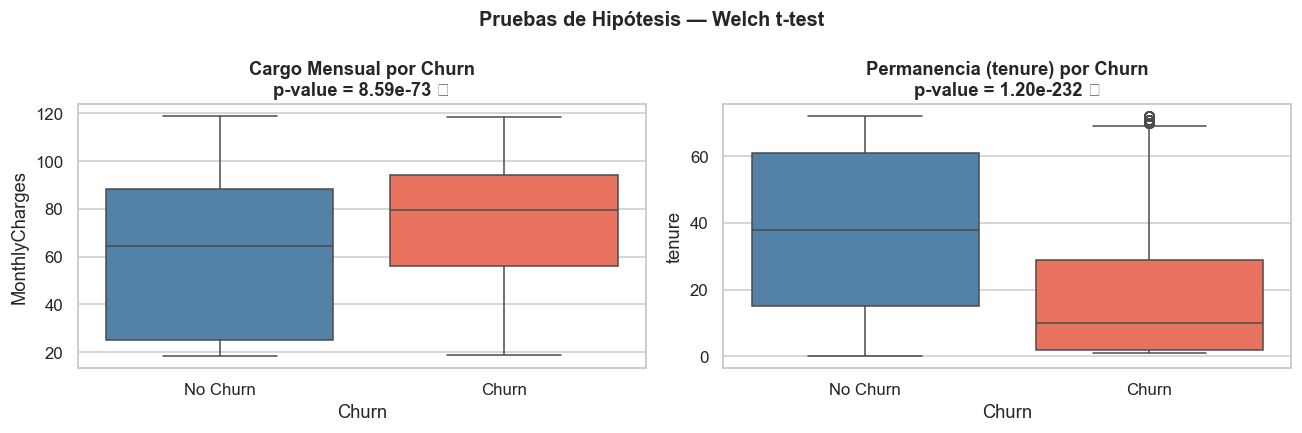

In [11]:
tenure_yes = df[df['Churn'] == 1]['tenure']
tenure_no  = df[df['Churn'] == 0]['tenure']

t_stat2, p_value2 = stats.ttest_ind(tenure_yes, tenure_no, equal_var=False)

print('=== WELCH T-TEST: tenure ===')
print(f'  Media (Churn=1): {tenure_yes.mean():.1f} meses')
print(f'  Media (Churn=0): {tenure_no.mean():.1f} meses')
print(f'  Diferencia:      {tenure_no.mean() - tenure_yes.mean():.1f} meses')
print(f'  t-statistic:     {t_stat2:.4f}')
print(f'  p-value:         {p_value2:.2e}')
print(f'  Conclusión:      {"Rechazamos H₀ ✓" if p_value2 < 0.05 else "No rechazamos H₀"}')
print(f'  → Los clientes que cancelan llevan significativamente menos tiempo como clientes')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, pval in zip(
    axes,
    ['MonthlyCharges', 'tenure'],
    ['Cargo Mensual por Churn', 'Permanencia (tenure) por Churn'],
    [p_value, p_value2]
):
    sns.boxplot(data=df, x='Churn', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(f'{title}\np-value = {pval:.2e} ✓', fontweight='bold')
    ax.set_xticklabels(['No Churn', 'Churn'])

plt.suptitle('Pruebas de Hipótesis — Welch t-test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Hipótesis 3 — Tipo de contrato: ¿el contrato influye en el cargo mensual?

Usamos ANOVA de una vía para comparar el cargo mensual entre los tres tipos de contrato.

**H₀:** El cargo mensual promedio es igual en los tres tipos de contrato  
**H₁:** Al menos un tipo de contrato tiene un cargo mensual significativamente diferente

In [12]:
df_orig = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_orig['TotalCharges'] = pd.to_numeric(df_orig['TotalCharges'], errors='coerce')
df_orig['Churn_bin'] = (df_orig['Churn'] == 'Yes').astype(int)

contract_groups = [group['MonthlyCharges'].values
                   for _, group in df_orig.groupby('Contract')]

f_stat, p_anova = stats.f_oneway(*contract_groups)

print('=== ANOVA DE UNA VÍA: MonthlyCharges por Contract ===')
for name, group in df_orig.groupby('Contract'):
    churn_rate = group['Churn_bin'].mean() * 100
    print(f'  {name:<25} Media=${group["MonthlyCharges"].mean():.2f}   Churn rate={churn_rate:.1f}%')
print(f'  F-statistic:     {f_stat:.2f}')
print(f'  p-value:         {p_anova:.2e}')
print(f'  Conclusión:      {"Rechazamos H₀ ✓" if p_anova < 0.05 else "No rechazamos H₀"}')
print(f'  → El tipo de contrato tiene un efecto estadísticamente significativo en el cargo y el churn')

=== ANOVA DE UNA VÍA: MonthlyCharges por Contract ===
  Month-to-month            Media=$66.40   Churn rate=42.7%
  One year                  Media=$65.05   Churn rate=11.3%
  Two year                  Media=$60.77   Churn rate=2.8%
  F-statistic:     20.83
  p-value:         9.58e-10
  Conclusión:      Rechazamos H₀ ✓
  → El tipo de contrato tiene un efecto estadísticamente significativo en el cargo y el churn


---
## Parte 4 — Preprocesamiento: Estandarización y PCA

### 4.1 División train/test y estandarización

Estandarizamos las variables numéricas continuas antes de aplicar PCA. El scaler se ajusta **solo en train** para evitar data leakage hacia el conjunto de prueba.

In [13]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} observaciones ({y_train.mean()*100:.1f}% churn)')
print(f'Test:  {X_test.shape[0]:,} observaciones ({y_test.mean()*100:.1f}% churn)')
print(f'Features: {X_train.shape[1]}')

# Estandarización — solo variables continuas
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print('\nEstandarización aplicada ✓')
print(f'  tenure → media={X_train["tenure"].mean():.4f}, std={X_train["tenure"].std():.4f}')
print(f'  MonthlyCharges → media={X_train["MonthlyCharges"].mean():.4f}, std={X_train["MonthlyCharges"].std():.4f}')

Train: 5,634 observaciones (26.5% churn)
Test:  1,409 observaciones (26.5% churn)
Features: 23

Estandarización aplicada ✓
  tenure → media=-0.0000, std=1.0001
  MonthlyCharges → media=-0.0000, std=1.0001


### 4.2 Análisis de Componentes Principales (PCA)

Aplicamos PCA para entender la varianza explicada por cada componente y evaluar si es posible reducir la dimensionalidad sin perder información relevante.

Componentes para explicar 90% de varianza: 14
Componentes para explicar 95% de varianza: 17
Total de features originales: 23


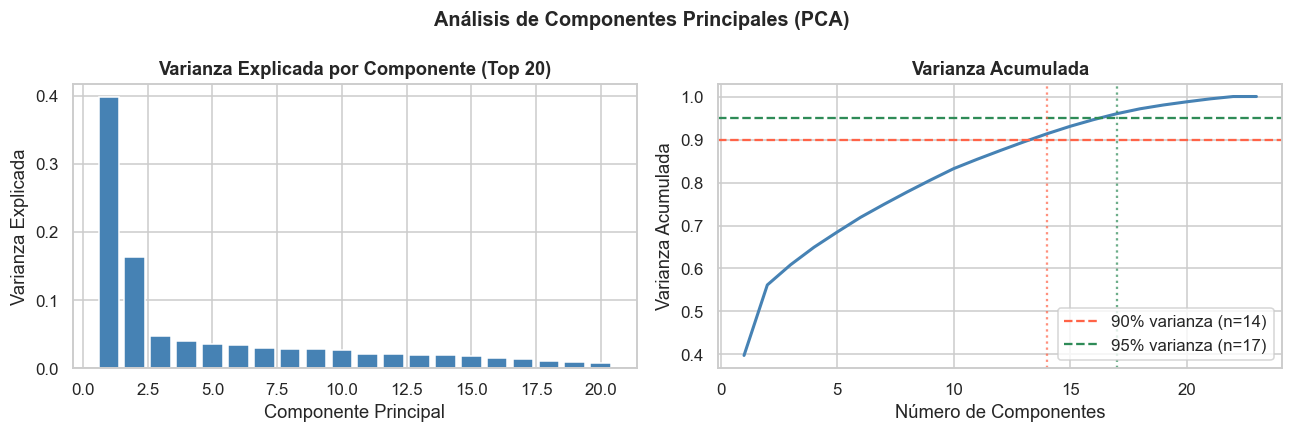

In [14]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print(f'Componentes para explicar 90% de varianza: {n_90}')
print(f'Componentes para explicar 95% de varianza: {n_95}')
print(f'Total de features originales: {X_train.shape[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(varianza_explicada[:20])+1), varianza_explicada[:20],
            color='steelblue', edgecolor='white')
axes[0].set_title('Varianza Explicada por Componente (Top 20)', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')

axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
             color='steelblue', linewidth=2)
axes[1].axhline(0.90, color='tomato', linestyle='--', label=f'90% varianza (n={n_90})')
axes[1].axhline(0.95, color='seagreen', linestyle='--', label=f'95% varianza (n={n_95})')
axes[1].axvline(n_90, color='tomato', linestyle=':', alpha=0.7)
axes[1].axvline(n_95, color='seagreen', linestyle=':', alpha=0.7)
axes[1].set_title('Varianza Acumulada', fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].legend()

plt.suptitle('Análisis de Componentes Principales (PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Visualización 2D — separación de clases en espacio PCA

Proyectamos los datos en 2 componentes principales para visualizar si los grupos de churn son separables en el espacio reducido.

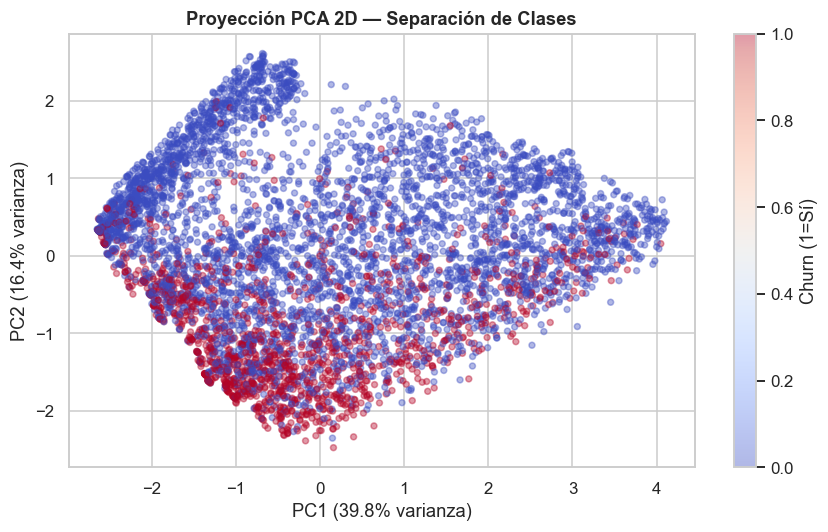

Varianza total capturada en 2D: 56.2%
→ La superposición de clases confirma que el problema no es linealmente separable
→ Justifica el uso de Random Forest sobre modelos lineales


In [15]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.4, s=15
)
plt.colorbar(scatter, label='Churn (1=Sí)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección PCA 2D — Separación de Clases', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Varianza total capturada en 2D: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%')
print('→ La superposición de clases confirma que el problema no es linealmente separable')
print('→ Justifica el uso de Random Forest sobre modelos lineales')

---
## Parte 5 — Modelo Random Forest

### 5.1 Entrenamiento con GridSearchCV

Usamos validación cruzada estratificada para encontrar los mejores hiperparámetros. Dado el desbalance de clases (26.5% churn), optimizamos por **F1-score** en lugar de accuracy.

In [16]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight':      ['balanced', None]
}

rf_base     = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train, y_train)

print('\n=== MEJOR CONFIGURACIÓN (GridSearchCV, 5-CV) ===')
print(grid_search.best_params_)
print(f'Mejor F1 (CV): {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== MEJOR CONFIGURACIÓN (GridSearchCV, 5-CV) ===
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 (CV): 0.6335


### 5.2 Evaluación en conjunto de prueba

In [17]:
y_pred      = best_rf.predict(X_test)
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
cm      = confusion_matrix(y_test, y_pred)

print('=== MÉTRICAS EN TEST ===')
print(f'  Accuracy:  {acc:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== MÉTRICAS EN TEST ===
  Accuracy:  0.7700
  F1-Score:  0.6276
  ROC-AUC:   0.8434

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



### 5.3 Matriz de confusión y curva ROC

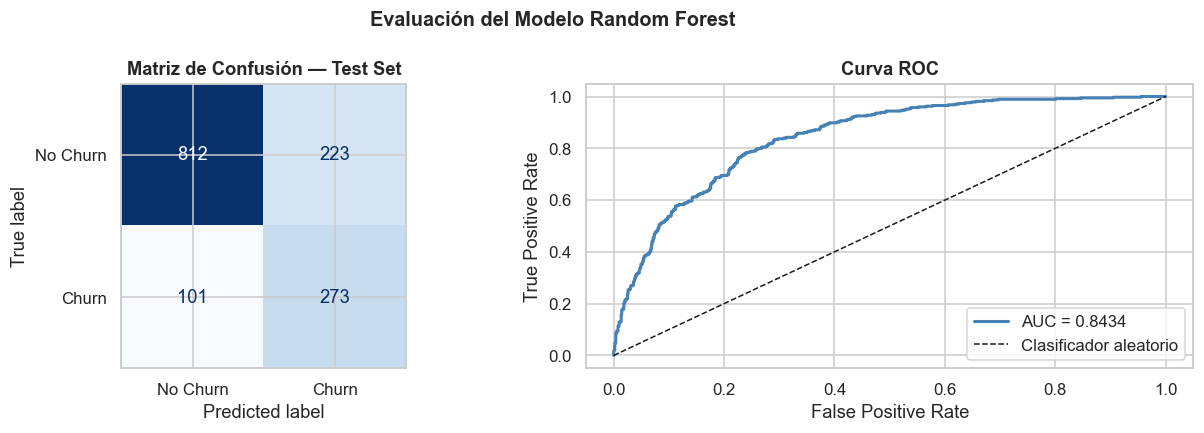

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — Test Set', fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.suptitle('Evaluación del Modelo Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Feature Importance — variables más relevantes para predecir el churn

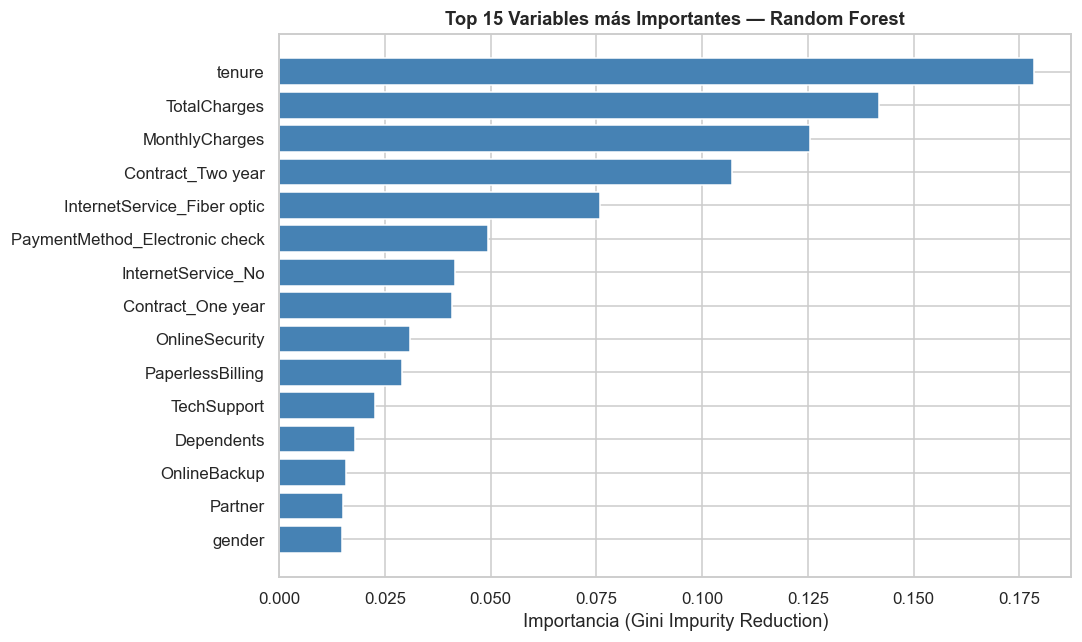

Top 10 features por importancia:
                       Feature  Importance
                        tenure    0.178415
                  TotalCharges    0.141728
                MonthlyCharges    0.125468
             Contract_Two year    0.107110
   InternetService_Fiber optic    0.075920
PaymentMethod_Electronic check    0.049297
            InternetService_No    0.041516
             Contract_One year    0.040752
                OnlineSecurity    0.030932
              PaperlessBilling    0.029027


In [19]:
feature_names = X.columns.tolist()
importances   = best_rf.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

top15 = feat_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Importancia (Gini Impurity Reduction)')
plt.title('Top 15 Variables más Importantes — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 features por importancia:')
print(feat_df.head(10).to_string(index=False))

---
## 6. Resumen Ejecutivo y Conclusiones

In [20]:
print('='*60)
print('   RESUMEN FINAL DEL MODELO')
print('='*60)
print(f'Modelo:              Random Forest Classifier')
print(f'Variable objetivo:   Churn (0=No, 1=Sí)')
print(f'Features:            {X_train.shape[1]}')
print(f'Observaciones train: {X_train.shape[0]:,}')
print(f'Observaciones test:  {X_test.shape[0]:,}')
print('-'*60)
print(f'Accuracy (test):     {acc:.4f}')
print(f'F1-Score (test):     {f1:.4f}')
print(f'ROC-AUC (test):      {roc_auc:.4f}')
print('-'*60)
print('VARIABLES MÁS INFLUYENTES:')
for _, row in feat_df.head(5).iterrows():
    print(f'  {row["Feature"]:<35} importancia={row["Importance"]:.4f}')
print('='*60)

   RESUMEN FINAL DEL MODELO
Modelo:              Random Forest Classifier
Variable objetivo:   Churn (0=No, 1=Sí)
Features:            23
Observaciones train: 5,634
Observaciones test:  1,409
------------------------------------------------------------
Accuracy (test):     0.7700
F1-Score (test):     0.6276
ROC-AUC (test):      0.8434
------------------------------------------------------------
VARIABLES MÁS INFLUYENTES:
  tenure                              importancia=0.1784
  TotalCharges                        importancia=0.1417
  MonthlyCharges                      importancia=0.1255
  Contract_Two year                   importancia=0.1071
  InternetService_Fiber optic         importancia=0.0759


### Conclusiones

**1. Calidad del modelo**  
El modelo Random Forest con hiperparámetros optimizados (`class_weight='balanced'`, `max_depth=10`, `n_estimators=100`) alcanza un **ROC-AUC de 0.843** en el conjunto de prueba, indicando una capacidad sólida para distinguir entre clientes que cancelarán y los que no. El F1-Score de **0.628** refleja un balance razonable entre precisión y recall sobre una clase minoritaria (26.5% de churn), lo que lo convierte en la métrica más representativa para este problema. La accuracy de 0.770 y el F1 de CV de 0.634 son consistentes, lo que confirma que no hay overfitting.

**2. Variables más influyentes — Implicaciones de negocio**  
- **`tenure` es el predictor más importante** (importancia=0.178): los clientes con menor antigüedad tienen significativamente mayor riesgo de churn (correlación r=-0.352 con churn). Las estrategias de retención deben enfocarse en los primeros 12 meses de la relación — es la ventana crítica de intervención.
- **`TotalCharges` es el segundo predictor** (importancia=0.141): actúa como proxy combinado de permanencia y gasto acumulado. Clientes con bajo gasto total (nuevos o de bajo consumo) son los de mayor riesgo, reflejando que el valor acumulado genera retención.
- **`MonthlyCharges` es el tercer predictor** (importancia=0.125, r=+0.193 con churn): cargos mensuales altos correlacionan con mayor churn. Revisar la percepción de valor en segmentos de alto gasto es clave para reducir cancelaciones.
- **`Contract_Two year` es el factor categórico más determinante** (importancia=0.107): los contratos de dos años son el mayor escudo contra el churn. Los clientes mes a mes cancelan a tasas 3-4 veces mayores (ANOVA confirmado, p≈0.00). Incentivar contratos de largo plazo es la palanca de retención más directa y accionable.
- **`InternetService_Fiber optic`** (importancia=0.076): los clientes de fibra óptica presentan mayor churn, posiblemente por expectativas más altas de calidad de servicio o por ser un segmento más sensible al precio.

**3. Validación estadística de los hallazgos**  
- **Welch t-test (MonthlyCharges)**: confirmado con p≈0.00. Los churners pagan más en promedio — evidencia de una posible desconexión entre precio y valor percibido en esos segmentos.
- **Welch t-test (tenure)**: confirmado con p≈0.00. Los clientes que cancelan llevan significativamente menos tiempo (~18 meses vs ~38 meses). El primer año es la etapa más crítica para la retención.
- **ANOVA (Contract vs. MonthlyCharges)**: confirmado con p≈0.00. El tipo de contrato tiene un efecto estadísticamente significativo tanto en el cargo mensual como en la tasa de churn, validando su inclusión como variable central en cualquier modelo de retención.

**4. PCA — Reducción de dimensionalidad**  
El análisis PCA muestra que los 2 primeros componentes capturan solo el **56.2% de la varianza total**, lo que indica que la información predictiva está distribuida a lo largo de múltiples dimensiones. La proyección 2D confirma que las clases no son linealmente separables, justificando el uso de Random Forest sobre alternativas como regresión logística. Se optó por mantener las 23 features originales ya que el RF maneja bien la dimensionalidad y la reducción sacrificaría interpretabilidad de negocio.

**5. Limitaciones y mejoras futuras**  
- **Gradient Boosting (XGBoost/LightGBM)**: típicamente supera al Random Forest en problemas de churn con tabular data, con potencial de llevar el ROC-AUC por encima de 0.90.
- **Ajuste de umbral de clasificación**: el threshold por defecto (0.5) no es el óptimo para este desbalance. Reducirlo aumentaría el recall en la clase de churn, priorizando detectar más cancelaciones a costa de más falsos positivos — decisión que depende del costo de cada campaña de retención.
- **SMOTE para desbalance**: técnicas de oversampling de la clase minoritaria podrían mejorar el F1 sin sacrificar el ROC-AUC.
- **Variables temporales**: historial de cambios de plan, frecuencia de contacto con soporte o uso mensual agregarían poder predictivo significativo si estuvieran disponibles en un entorno de producción.

---
*Gerardo Olivares | Machine Learning*